Node: Feature 2, Threshold 3.0
Left:
  Leaf: Class = 0
Right:
  Leaf: Class = 1
Accuracy at depth 1: 0.633333



Node: Feature 2, Threshold 3.0
Left:
  Leaf: Class = 0
Right:
  Node: Feature 2, Threshold 4.7
  Left:
    Leaf: Class = 1
  Right:
    Leaf: Class = 2
Accuracy at depth 2: 0.966667



Node: Feature 2, Threshold 3.0
Left:
  Leaf: Class = 0
Right:
  Node: Feature 2, Threshold 4.7
  Left:
    Leaf: Class = 1
  Right:
    Node: Feature 3, Threshold 1.7
    Left:
      Leaf: Class = 2
    Right:
      Leaf: Class = 2
Accuracy at depth 3: 0.966667



Node: Feature 2, Threshold 3.0
Left:
  Leaf: Class = 0
Right:
  Node: Feature 2, Threshold 4.7
  Left:
    Leaf: Class = 1
  Right:
    Node: Feature 3, Threshold 1.7
    Left:
      Node: Feature 2, Threshold 5.0
      Left:
        Leaf: Class = 1
      Right:
        Leaf: Class = 2
    Right:
      Leaf: Class = 2
Accuracy at depth 4: 1.000000



Node: Feature 2, Threshold 3.0
Left:
  Leaf: Class = 0
Right:
  Node: Feature 2, Thr

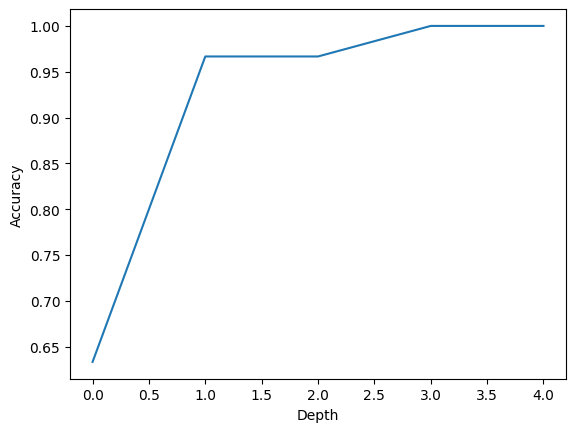

In [62]:
from collections import Counter
import numpy as np
from sklearn import datasets
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy

def entropy(x):

    if len(x) == 0:
        return 0

    class_counts = Counter(x)

    entropy_value = 0
    total_samples = len(x)

    for count in class_counts.values():
        probability = count / total_samples
        entropy_value -= probability * np.log2(probability)
    #print('entropy : ',entropy_value)
    return entropy_value

    pass

class Node:
    def __init__(self, feature, threshold, left, right, *, value):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

class TreeRegressor:
    def __init__(self, min_samples_split=2, max_depth=100, n_feats=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self.build_tree(X, y)

    def predict(self, X):

        predictions = []
        for x in X:
            prediction = self.traverse_tree(x, self.root)
            predictions.append(prediction)
        #print(f"Prediction for {x}: {prediction}")
        return np.array(predictions)

    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape

        # Stopping criteria:
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(None,None,None,None,value=self.common_thing(y))
        # Try to find the best split
        best_split = self.get_best_split(X, y, feat_idxs=range(n_features))
        
        # If there's no best split, stop and return the common value
        if best_split is None:
            return Node(None,None,None,None,value=self.common_thing(y))

        feature, threshold, left_indices, right_indices, info_gain = best_split

        # Recursively build the left and right subtrees
        left_subtree = self.build_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self.build_tree(X[right_indices], y[right_indices], depth + 1)

        return Node(feature, threshold, left=left_subtree, right=right_subtree, value=None)

    def get_best_split(self, X, y, feat_idxs):
        best_split = None
        best_info_gain = -1  # Initialize with a negative value
        
        for feature in feat_idxs:
            feature_values = X[:, feature]
            unique_values = np.unique(feature_values)
            for threshold in unique_values:
                left_indices , right_indices = self.split(feature_values,threshold)

                if len(np.unique(y[left_indices])) == 1 or len(np.unique(y[right_indices])) == 1:
                    # skip pure splits
                    continue
                if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
                    # Skip splits with no data on one side
                    continue

                info_gain = self.information_gain(y, feature_values, threshold)

                if info_gain > best_info_gain:
                    best_info_gain = info_gain
                    best_split = (feature, threshold, left_indices, right_indices, best_info_gain)

        return best_split


    def information_gain(self, y, X_column, split_thresh):
        parent_entropy = entropy(y)

        # Split the labels into left and right based on the threshold
        left_indices, right_indices = self.split(X_column,split_thresh)

        # Calculate the weighted average of child entropies
        left_entropy = entropy(y[left_indices])
        right_entropy  = entropy(y[right_indices])
        # Calculate information gain
        info_gain = parent_entropy - ((np.sum(left_indices) / len(y)) * left_entropy) - ((np.sum(right_indices) / len(y)) * right_entropy)
        return info_gain


    def split(self, X_column, split_thresh):
        left_indices = X_column <= split_thresh
        right_indices = X_column > split_thresh
        return left_indices, right_indices


    def traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self.traverse_tree(x, node.left)
        else:
            return self.traverse_tree(x, node.right)


    def common_thing(self, y):
        count = Counter(y)
        if not count:
            return None
        common_thing = count.most_common(1)[0][0]
        return common_thing
def print_tree(node, depth=0):
    """Recursively prints the structure of the tree."""
    if node is None:
        return
    
    if node.is_leaf():
        print(f"{'  ' * depth}Leaf: Class = {node.value}")
    else:
        print(f"{'  ' * depth}Node: Feature {node.feature}, Threshold {node.threshold}")
        
        # Recursively print the left and right subtrees
        print(f"{'  ' * depth}Left:")
        print_tree(node.left, depth + 1)
        
        print(f"{'  ' * depth}Right:")
        print_tree(node.right, depth + 1)

if __name__ == "__main__":

    data = datasets.load_iris()
    X, y = data.data, data.target
    #print(X)
    #print(y)
    #scaler = StandardScaler()
    #X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    accuracy_depths = []
    for depth in range(1, 6):   
        clf = TreeRegressor(min_samples_split=2,max_depth=depth)
        print_tree(clf.root)
        clf.fit(X_train, y_train)
        print_tree(clf.root)
        y_pred = clf.predict(X_test)
        #print(f"Predictions: {y_pred}")
        acc = accuracy(y_test, y_pred)
        accuracy_depths.append(acc)
        print("Accuracy at depth %d: %f" % (depth, acc))
        print('\n\n')
    #sns.pairplot(pd.DataFrame(X, columns=['sepal.length', 'sepal.width', 'petal.length', 'petal.width']), hue='variety')
    #plt.show()
    # plot_decision_boundary(X_train[:, :4], y_train, clf, title="Decision Boundary for Depth 1")
    plt.figure()
    plt.plot(accuracy_depths)
    plt.xlabel("Depth")
    plt.ylabel("Accuracy")
    plt.show()